# Exploratory data analysis

## Imports

In [10]:
#Algebra
import numpy as np

#Graphics
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

#Deep learning
import tensorflow as tf
from keras.models import Model
from keras import Input, layers, optimizers, callbacks

from keras.utils import image_dataset_from_directory

#Pretrained model for transfer learning


#Saving models
import joblib

## Dataset paths

In [6]:
train_data_dir = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color'

## Example image from training set

In [2]:
image_path = '/kaggle/input/datasets/aayush9753/image-colorization-dataset/data/train_color/image0001.jpg'

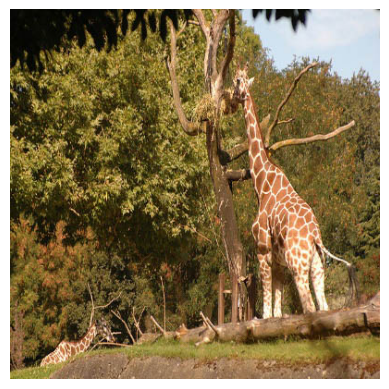

In [3]:
img = np.array(Image.open(image_path))
plt.imshow(img)
plt.axis('off');

In [4]:
img.shape

(400, 400, 3)

In [5]:
BATCH_SIZE = 32

IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)
NUM_CHANNELS = 3

SEED = 42

In [12]:
train_ds = image_dataset_from_directory(
    train_data_dir,
    labels=None,
    seed=SEED,
    validation_split=0.2,
    subset='training',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE)

Found 5000 files.
Using 4000 files for training.


In [8]:
train_ds

<_PrefetchDataset element_spec=TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None)>

In [55]:
import tensorflow_io as tfio

def rgb_to_lab(images):
    images = tf.cast(images, tf.float32) / 255.0
    lab = tfio.experimental.color.rgb_to_lab(images)
    L = lab[:, :, :, :1]
    ab = lab[:, :, :, 1:]
    return (L, ab)

In [56]:
train_ds_lab = train_ds.map(rgb_to_lab, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_lab = train_ds_lab.prefetch(tf.data.AUTOTUNE)

In [57]:
train_ds_lab

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 2), dtype=tf.float32, name=None))>

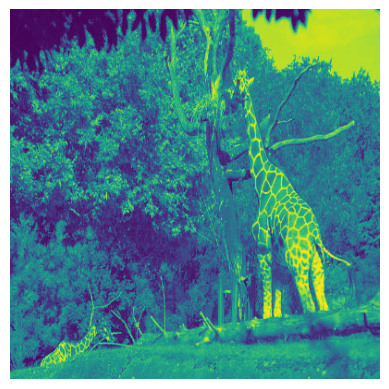

In [63]:
L, ab = rgb_to_lab(np.expand_dims(img, axis=0))
plt.imshow(np.squeeze(L, axis=0))
plt.axis('off');

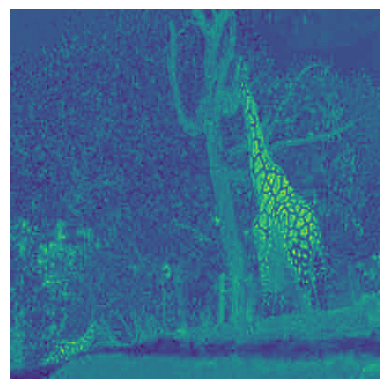

In [64]:
plt.imshow(np.squeeze(ab, axis=0)[:,:,0])
plt.axis('off');

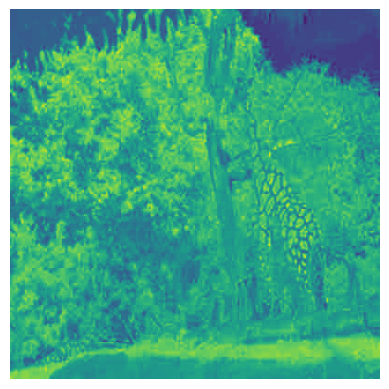

In [65]:
plt.imshow(np.squeeze(ab, axis=0)[:,:,1])
plt.axis('off');